Centered slippage + non-centered liability with meta-experts
------------------------------------------------------------
Liquidity levels: low b = 1, high b = 12
beta_mix = 1.000
SLIP_SCALE = 1.000, LIAB_SCALE = 4.000
eta_meta = 0.001, alpha_meta = 0.000
Coefficient profiles [a, b]:
  profile 0: [6.000, 0.200]
  profile 1: [3.000, 0.700]
  profile 2: [1.500, 1.500]
  profile 3: [0.700, 3.000]
  profile 4: [0.200, 6.000]

Mean fee_t   = 0.000752
Max fee_t    = 0.003641
Final z_T    = 0.115058
Final w_b    = [0.538 0.462] [low, high]
Final b_eff  = 2.7811
Final coeff marginal = [0.2146 0.2107 0.2047 0.1942 0.1758]


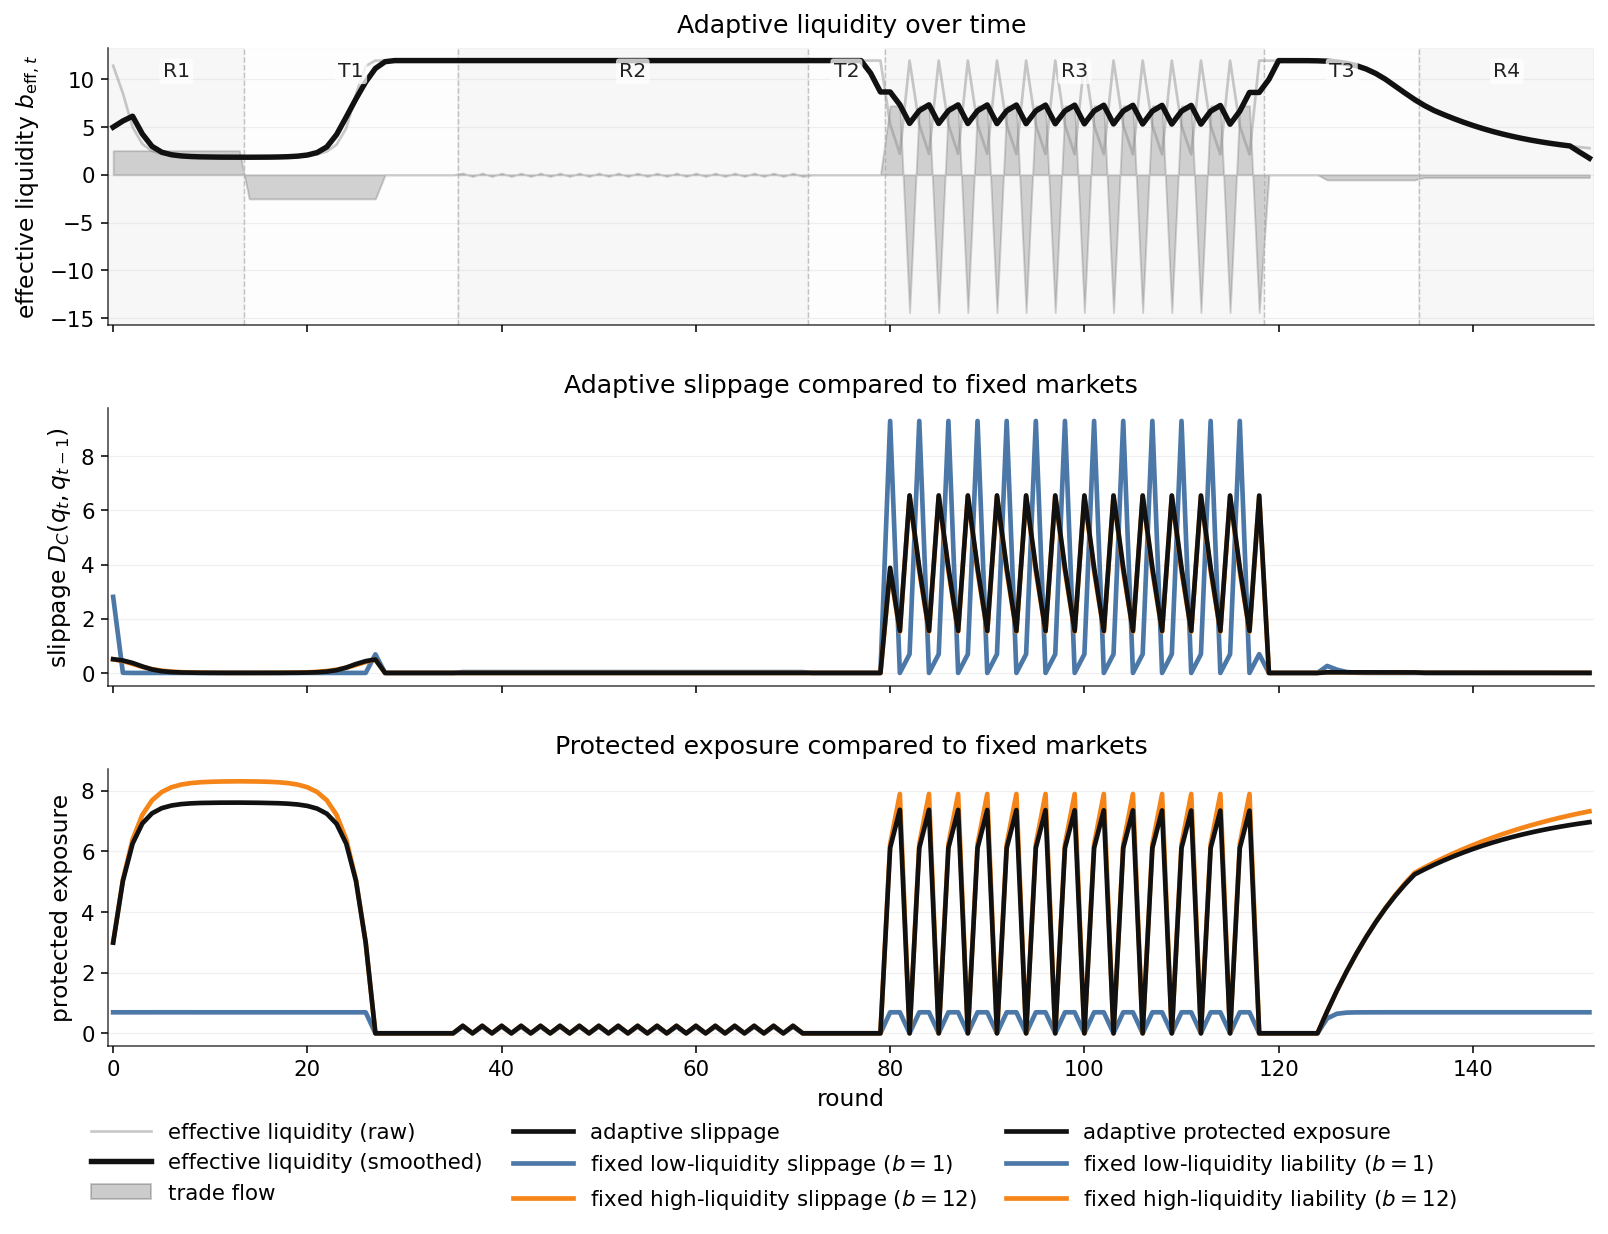

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


# ============================================================
# Adaptive liquidity with CENTERED SLIPPAGE + NON-CENTERED LIABILITY
# ------------------------------------------------------------
# This simulation compares two fixed LMSR liquidity experts and an
# adaptive mixed market that routes weight between them using a
# meta-learner (Fixed-Share).
#
# ------------------------------------------------------------
# SIGNAL USED BY THE LEARNER
# ------------------------------------------------------------
# For each liquidity expert k and coefficient profile m, we define
# the per-round loss
#
#   Gamma_{k,m,t}
#   = a_m * centered_slippage_{k,t} / SLIP_SCALE
#   + b_m * liability_tilde_{k,t}   / LIAB_SCALE
#
# where:
#
#   slippage_{k,t}
#   = D_{C_k}(q_t, q_{t-1})
#   = C_k(q_t) - C_k(q_{t-1}) - <grad C_k(q_{t-1}), r_t>
#
# is the Bregman divergence / curvature-induced trading cost for
# expert k on round t.
#
# We CENTER ONLY THE SLIPPAGE TERM:
#
#   centered_slippage_{k,t}
#   = slippage_{k,t} - average_j slippage_{j,t}
#
# Why center slippage?
#   In large-trade regimes, both experts can have large raw slippage.
#   Without centering, the learner sees both as "bad" in absolute
#   terms and becomes less responsive. Centering restores a relative
#   comparison:
#
#       "which expert has lower slippage than the others THIS round?"
#
# We DO NOT center the liability term:
#
#   liability_tilde_{k,t}
#   = max_omega [ rho(omega)·q_t - C_tilde_k(q_t) ]
#
# Why keep liability non-centered?
#   This preserves the economic interpretation of liability as an
#   absolute inventory-risk quantity. The learner is then balancing:
#
#     - relative liquidity quality this round (centered slippage)
#     - absolute current exposure (non-centered liability)
#
# Lower Gamma is better, so the learner favors experts with:
#   - lower-than-average slippage, and
#   - lower absolute liability.
#
# ------------------------------------------------------------
# MIXED MARKET AND FEE
# ------------------------------------------------------------
# The adaptive market shown in the plots uses the marginal weights
# over liquidity experts, producing a mixed market
#
#   C_mix(q; w) = (1/beta_mix) log sum_k w_k exp(beta_mix C_k(q)).
#
# We also include the positive switching fee
#
#   fee_t = [Delta_t^*]_+
#
# where Delta_t^* is approximated by a 1D grid search in the binary
# LMSR case.
#
# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------
# Panel 1: effective liquidity over time
# Panel 2: adaptive slippage compared to fixed markets
# Panel 3: protected exposure compared to fixed markets
#
# Protected exposure is:
#
#   max( mixed liability - cumulative fee budget, 0 )
#
# ============================================================


# ============================================================
# 1. LMSR helpers
# ============================================================

def lmsr_cost(q: np.ndarray, b: float) -> float:
    """
    LMSR cost:
        C(q) = b log(sum_i exp(q_i / b))
    """
    q = np.asarray(q, dtype=float)
    x = q / b
    m = np.max(x)
    return float(b * (m + np.log(np.sum(np.exp(x - m)))))


def lmsr_price(q: np.ndarray, b: float) -> np.ndarray:
    """
    LMSR instantaneous price = gradient of LMSR cost.
    """
    q = np.asarray(q, dtype=float)
    x = q / b
    m = np.max(x)
    z = np.exp(x - m)
    return z / np.sum(z)


def lmsr_cost0(b: float, num_outcomes: int) -> float:
    """
    Baseline cost at q = 0.
    """
    return float(b * np.log(num_outcomes))


def lmsr_cost_tilde(q: np.ndarray, b: float) -> float:
    """
    Centered cost:
        C_tilde(q) = C(q) - C(0)
    """
    return lmsr_cost(q, b) - lmsr_cost0(b, len(q))


def lmsr_liability_tilde(q: np.ndarray, b: float, payoff_vectors: np.ndarray) -> float:
    """
    Centered liability:
        L_tilde(q) = max_omega [ rho(omega)·q - C_tilde(q) ]
    """
    c_tilde = lmsr_cost_tilde(q, b)
    vals = payoff_vectors @ q - c_tilde
    return float(np.max(vals))


def lmsr_slippage(q_prev: np.ndarray, r: np.ndarray, b: float) -> float:
    """
    Slippage / Bregman divergence:
        D_C(q+r, q) = C(q+r) - C(q) - <grad C(q), r>
    """
    q_next = q_prev + r
    return float(
        lmsr_cost(q_next, b)
        - lmsr_cost(q_prev, b)
        - np.dot(lmsr_price(q_prev, b), r)
    )


# ============================================================
# 2. Mixed market helpers
# ============================================================

def mixed_cost(q: np.ndarray, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> float:
    """
    Mixed cost:
        C_mix(q; w) = (1/beta_mix) log(sum_k w_k exp(beta_mix C_k(q)))
    """
    vals = np.array([lmsr_cost(q, b) for b in bs], dtype=float)
    z = beta_mix * vals
    m = np.max(z)
    return float((m + np.log(np.sum(w_b * np.exp(z - m)))) / beta_mix)


def mixed_cost0(w_b: np.ndarray, bs: np.ndarray, beta_mix: float, d: int) -> float:
    """
    Baseline mixed cost at q = 0.
    """
    return mixed_cost(np.zeros(d, dtype=float), w_b, bs, beta_mix)


def mixed_cost_tilde(q: np.ndarray, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> float:
    """
    Centered mixed cost:
        C_mix_tilde(q) = C_mix(q) - C_mix(0)
    """
    return mixed_cost(q, w_b, bs, beta_mix) - mixed_cost0(w_b, bs, beta_mix, len(q))


def pricing_weights(q: np.ndarray, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> np.ndarray:
    """
    Posterior pricing weights induced by the log-sum-exp mixture.
    """
    vals = np.array([lmsr_cost(q, b) for b in bs], dtype=float)
    logits = np.log(np.maximum(w_b, 1e-300)) + beta_mix * vals
    logits -= np.max(logits)
    z = np.exp(logits)
    return z / np.sum(z)


def mixed_price(q: np.ndarray, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> np.ndarray:
    """
    Mixed price vector:
        grad C_mix(q) = sum_k pi_k(q) grad C_k(q)
    """
    pi = pricing_weights(q, w_b, bs, beta_mix)
    prices = np.array([lmsr_price(q, b) for b in bs], dtype=float)
    return np.sum(pi[:, None] * prices, axis=0)


def mixed_slippage(q_prev: np.ndarray, r: np.ndarray, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> float:
    """
    Mixed slippage / Bregman divergence:
        D_{C_mix}(q+r, q)
    """
    q_next = q_prev + r
    return float(
        mixed_cost(q_next, w_b, bs, beta_mix)
        - mixed_cost(q_prev, w_b, bs, beta_mix)
        - np.dot(mixed_price(q_prev, w_b, bs, beta_mix), r)
    )


def mixed_liability_tilde(
    q: np.ndarray,
    w_b: np.ndarray,
    bs: np.ndarray,
    beta_mix: float,
    payoff_vectors: np.ndarray,
) -> float:
    """
    Centered mixed liability:
        L_mix_tilde(q) = max_omega [ rho(omega)·q - C_mix_tilde(q) ]
    """
    c_tilde = mixed_cost_tilde(q, w_b, bs, beta_mix)
    vals = payoff_vectors @ q - c_tilde
    return float(np.max(vals))


# ============================================================
# 3. Positive switch fee [Delta_t^*]_+
# ============================================================

def mixed_cost_from_x(x: float, w_b: np.ndarray, bs: np.ndarray, beta_mix: float) -> float:
    """
    Binary LMSR reduction using x = q1 - q2.
    """
    q = np.array([x, 0.0], dtype=float)
    return mixed_cost(q, w_b, bs, beta_mix)


def positive_switch_fee(
    w_old: np.ndarray,
    w_new: np.ndarray,
    bs: np.ndarray,
    beta_mix: float,
    x_grid: np.ndarray,
) -> float:
    """
    Approximate:
        fee_t = [Delta_t^*]_+
    where
        Delta_t^* = sup_x ( C_mix(x; w_old) - C_mix(x; w_new) ).
    """
    diffs = np.array([
        mixed_cost_from_x(x, w_old, bs, beta_mix)
        - mixed_cost_from_x(x, w_new, bs, beta_mix)
        for x in x_grid
    ], dtype=float)
    delta_star = float(np.max(diffs))
    return max(delta_star, 0.0)


# ============================================================
# 4. Fixed-Share learner
# ============================================================

def fixed_share_update(
    w: np.ndarray,
    losses: np.ndarray,
    eta: float,
    alpha: float,
    logit_clip: float = 50.0,
) -> np.ndarray:
    """
    Fixed-Share multiplicative update.
    """
    w = np.asarray(w, dtype=float)
    losses = np.asarray(losses, dtype=float)

    shift = np.min(losses)
    logits = np.log(np.maximum(w, 1e-300)) - eta * (losses - shift)
    logits -= np.max(logits)
    logits = np.clip(logits, -logit_clip, 0.0)

    v = np.exp(logits)
    v /= np.sum(v)

    M = len(w)
    w_next = (1.0 - alpha) * v + alpha * np.ones(M) / M
    w_next /= np.sum(w_next)
    return w_next


# ============================================================
# 5. Utilities
# ============================================================

def center_across_experts(x: np.ndarray) -> np.ndarray:
    """
    Cross-expert centering:
        x_k -> x_k - average_j x_j
    """
    return x - np.mean(x)


def rolling_mean(x: np.ndarray, window: int) -> np.ndarray:
    """
    Simple centered moving average used only for display.
    """
    if window <= 1:
        return x.copy()
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(x, kernel, mode="same")


# ============================================================
# 6. Regime schedule
# ============================================================

SEGMENT_NAMES = [
    "R1: Large directional trades",
    "T1: Inventory unwind",
    "R2: Small spread-capture trades",
    "T2: Neutralization",
    "R3: Rapid price discovery",
    "T3: Inventory build",
    "R4: Large inventory exposure",
]

IS_MAIN_REGIME = [True, False, True, False, True, False, True]


def build_trade_schedule():
    """
    Create the stylized regime schedule.
    """
    trades = []
    segment_ids = []
    starts = []

    # R1: large directional buys
    starts.append(len(trades))
    for _ in range(14):
        trades.append(np.array([7.0, 0.0], dtype=float))
        segment_ids.append(0)

    # T1: inventory neutralization after R1
    starts.append(len(trades))

    # unwind the R1 inventory more directly
    for _ in range(14):
        trades.append(np.array([-7.0, 0.0], dtype=float))
        segment_ids.append(1)

    # stabilization block near neutral inventory
    for _ in range(8):
        trades.append(np.array([0.0, 0.0], dtype=float))
        segment_ids.append(1)

    # R2: small oscillatory trades near neutral inventory
    starts.append(len(trades))
    for i in range(36):
        if i % 2 == 0:
            trades.append(np.array([0.25, -0.25], dtype=float))
        else:
            trades.append(np.array([-0.25, 0.25], dtype=float))
        segment_ids.append(2)

    # T2: neutral hold
    starts.append(len(trades))
    for _ in range(8):
        trades.append(np.array([0.0, 0.0], dtype=float))
        segment_ids.append(3)

    # R3: rapid price discovery
    starts.append(len(trades))
    pattern = [
        np.array([10.0, -10.0], dtype=float),
        np.array([10.0, -10.0], dtype=float),
        np.array([-20.0, 20.0], dtype=float),
    ]
    for _ in range(13):
        for p in pattern:
            trades.append(p.copy())
            segment_ids.append(4)

    trades = trades[:starts[-1] + 40]
    segment_ids = segment_ids[:starts[-1] + 40]

    # T3: inventory build
    starts.append(len(trades))
    for _ in range(6):
        trades.append(np.array([0.0, 0.0], dtype=float))
        segment_ids.append(5)
    for _ in range(10):
        trades.append(np.array([0.0, 1.5], dtype=float))
        segment_ids.append(5)

    # R4: persistent inventory exposure
    starts.append(len(trades))
    for _ in range(18):
        trades.append(np.array([0.0, 0.8], dtype=float))
        segment_ids.append(6)

    ends = starts[1:] + [len(trades)]
    return trades, segment_ids, starts, ends, SEGMENT_NAMES


# ============================================================
# 7. Plot helpers
# ============================================================

def add_regimes_clean(ax, starts, ends, short_names, is_main, show_labels=False):
    """
    Light regime shading for the plots.
    """
    for i, (s, e, name, main_flag) in enumerate(zip(starts, ends, short_names, is_main)):
        color = "#dcdcdc" if main_flag else "#f2f2f2"
        alpha = 0.22 if main_flag else 0.14
        ax.axvspan(s - 0.5, e - 0.5, color=color, alpha=alpha, zorder=0)

        if i > 0:
            ax.axvline(s - 0.5, color="#9a9a9a", linestyle="--", linewidth=0.75, alpha=0.55, zorder=1)

        if show_labels:
            mid = (s + e - 1) / 2.0
            y0, y1 = ax.get_ylim()
            y = y1 - 0.05 * (y1 - y0)
            ax.text(
                mid,
                y,
                name,
                ha="center",
                va="top",
                fontsize=10.5,
                color="#222222",
                bbox=dict(
                    boxstyle="round,pad=0.16",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                ),
                zorder=5,
            )


# ============================================================
# 8. Main simulation
# ============================================================

def main():
    # --------------------------------------------------------
    # Basic market setup
    # --------------------------------------------------------
    payoff_vectors = np.eye(2)

    # Two liquidity experts
    b_low = 1.0
    b_high = 12.0
    bs = np.array([b_low, b_high], dtype=float)
    num_liq = len(bs)

    # Mixture sharpness
    beta_mix = 1.0

    # --------------------------------------------------------
    # Meta-expert coefficient family
    # --------------------------------------------------------
    # Each meta-expert chooses how much weight to place on:
    #   - centered slippage
    #   - non-centered liability
    coeff_profiles = np.array([
        [6.0, 0.2],   # mostly slippage
        [3.0, 0.7],   # slippage leaning
        [1.5, 1.5],   # balanced
        [0.7, 3.0],   # liability leaning
        [0.2, 6.0],   # mostly liability
    ], dtype=float)
    num_coeff = len(coeff_profiles)

    # Signal scales
    SLIP_SCALE = 1.0
    LIAB_SCALE = 4.0

    # Learner hyperparameters: conservative values for positive-upside regime
    eta_meta = 5e-4
    alpha_meta = 1e-4

    # Fee approximation grid
    x_grid = np.linspace(-140.0, 140.0, 5001)

    # Plot smoothing
    roll_window = 5

    # Trade schedule
    trades, segment_ids, starts, ends, segment_names = build_trade_schedule()
    T = len(trades)

    # --------------------------------------------------------
    # States
    # --------------------------------------------------------
    # Fixed expert states
    q_experts = np.zeros((num_liq, 2), dtype=float)

    # Adaptive mixed market state
    q_adapt = np.zeros(2, dtype=float)

    # Meta-expert list:
    #   (liquidity index k, coeff profile index m, a_m, b_m)
    meta_list = []
    for k in range(num_liq):
        for m in range(num_coeff):
            a_m, b_m = coeff_profiles[m]
            meta_list.append((k, m, a_m, b_m))
    num_meta = len(meta_list)

    # Initial meta-weights
    w_meta = np.ones(num_meta, dtype=float) / num_meta

    # Cumulative fee reserve
    z_cum = 0.0

    # --------------------------------------------------------
    # Histories
    # --------------------------------------------------------
    trade_hist = []

    w_meta_hist = []
    w_to_b_hist = []
    w_to_coeff_hist = []
    b_eff_hist = []

    slip_expert_hist = []
    centered_slip_hist = []
    liab_expert_hist = []
    meta_losses_hist = []

    adapt_slip_hist = []
    adapt_mixed_liab_hist = []
    adapt_protected_exposure_hist = []

    fee_hist = []
    z_hist = []

    # --------------------------------------------------------
    # Main loop
    # --------------------------------------------------------
    for t in range(T):
        r_t = trades[t]

        # Fixed expert next states
        q_experts_next = q_experts + r_t

        # Expert slippage and liability
        slip_experts = np.array(
            [lmsr_slippage(q_experts[k], r_t, bs[k]) for k in range(num_liq)],
            dtype=float,
        )
        centered_slip = center_across_experts(slip_experts)

        liab_experts = np.array(
            [lmsr_liability_tilde(q_experts_next[k], bs[k], payoff_vectors) for k in range(num_liq)],
            dtype=float,
        )

        # ----------------------------------------------------
        # LEARNER SIGNAL
        # ----------------------------------------------------
        # We use:
        #   loss_{k,m,t} =
        #       a_m * centered_slip[k] / SLIP_SCALE
        #     + b_m * liab_experts[k] / LIAB_SCALE
        #
        # Interpretation:
        # - centered_slip[k] < 0 means expert k has lower slippage than average
        # - smaller liability is always better in absolute terms
        losses_meta = np.zeros(num_meta, dtype=float)
        for idx, (k, m, a_m, b_m) in enumerate(meta_list):
            losses_meta[idx] = (
                a_m * centered_slip[k] / SLIP_SCALE
                + b_m * liab_experts[k] / LIAB_SCALE
            )

        # Current marginal weights over liquidity experts
        w_to_b = np.zeros(num_liq, dtype=float)
        for k in range(num_liq):
            start = k * num_coeff
            end = (k + 1) * num_coeff
            w_to_b[k] = np.sum(w_meta[start:end])

        # Adaptive market diagnostics at current weights
        q_adapt_next = q_adapt + r_t
        adapt_slip = mixed_slippage(q_adapt, r_t, w_to_b, bs, beta_mix)

        # Update meta-weights
        w_meta_next = fixed_share_update(
            w_meta,
            losses_meta,
            eta=eta_meta,
            alpha=alpha_meta,
        )

        # New marginal weights over liquidity experts
        w_to_b_next = np.zeros(num_liq, dtype=float)
        for k in range(num_liq):
            start = k * num_coeff
            end = (k + 1) * num_coeff
            w_to_b_next[k] = np.sum(w_meta_next[start:end])

        # Positive fee
        fee_t = positive_switch_fee(
            w_old=w_to_b,
            w_new=w_to_b_next,
            bs=bs,
            beta_mix=beta_mix,
            x_grid=x_grid,
        )
        z_cum += fee_t

        # Mixed liability and protected exposure
        adapt_mixed_liab = mixed_liability_tilde(
            q=q_adapt_next,
            w_b=w_to_b_next,
            bs=bs,
            beta_mix=beta_mix,
            payoff_vectors=payoff_vectors,
        )
        #adapt_protected_exposure = max(adapt_mixed_liab - z_cum, 0.0)
        adapt_protected_exposure = max(adapt_mixed_liab, 0.0)

        # Commit updates
        q_experts = q_experts_next
        q_adapt = q_adapt_next
        w_meta = w_meta_next

        # Recompute marginals after update
        w_to_b = w_to_b_next

        w_to_coeff = np.zeros(num_coeff, dtype=float)
        for m in range(num_coeff):
            for k in range(num_liq):
                idx = k * num_coeff + m
                w_to_coeff[m] += w_meta[idx]

        #b_eff = float(np.dot(w_to_b, bs))
        pi_b = pricing_weights(q_adapt, w_to_b, bs, beta_mix)
        b_eff = 1.0 / np.sum(pi_b / bs)

        # Log histories
        trade_hist.append(r_t.copy())

        w_meta_hist.append(w_meta.copy())
        w_to_b_hist.append(w_to_b.copy())
        w_to_coeff_hist.append(w_to_coeff.copy())
        b_eff_hist.append(b_eff)

        slip_expert_hist.append(slip_experts.copy())
        centered_slip_hist.append(centered_slip.copy())
        liab_expert_hist.append(liab_experts.copy())
        meta_losses_hist.append(losses_meta.copy())

        adapt_slip_hist.append(adapt_slip)
        adapt_mixed_liab_hist.append(adapt_mixed_liab)
        adapt_protected_exposure_hist.append(adapt_protected_exposure)

        fee_hist.append(fee_t)
        z_hist.append(z_cum)

    # --------------------------------------------------------
    # Convert logs to arrays
    # --------------------------------------------------------
    trade_hist = np.array(trade_hist)

    w_meta_hist = np.array(w_meta_hist)
    w_to_b_hist = np.array(w_to_b_hist)
    w_to_coeff_hist = np.array(w_to_coeff_hist)
    b_eff_hist = np.array(b_eff_hist)

    slip_expert_hist = np.array(slip_expert_hist)
    centered_slip_hist = np.array(centered_slip_hist)
    liab_expert_hist = np.array(liab_expert_hist)
    meta_losses_hist = np.array(meta_losses_hist)

    adapt_slip_hist = np.array(adapt_slip_hist)
    adapt_mixed_liab_hist = np.array(adapt_mixed_liab_hist)
    adapt_protected_exposure_hist = np.array(adapt_protected_exposure_hist)

    fee_hist = np.array(fee_hist)
    z_hist = np.array(z_hist)

    b_eff_roll = rolling_mean(b_eff_hist, roll_window)

    # --------------------------------------------------------
    # Console summary
    # --------------------------------------------------------
    print("Centered slippage + non-centered liability with meta-experts")
    print("------------------------------------------------------------")
    print(f"Liquidity levels: low b = {b_low:g}, high b = {b_high:g}")
    print(f"beta_mix = {beta_mix:.3f}")
    print(f"SLIP_SCALE = {SLIP_SCALE:.3f}, LIAB_SCALE = {LIAB_SCALE:.3f}")
    print(f"eta_meta = {eta_meta:.3f}, alpha_meta = {alpha_meta:.3f}")
    print("Coefficient profiles [a, b]:")
    for m, (a, bcoef) in enumerate(coeff_profiles):
        print(f"  profile {m}: [{a:.3f}, {bcoef:.3f}]")
    print()
    print(f"Mean fee_t   = {np.mean(fee_hist):.6f}")
    print(f"Max fee_t    = {np.max(fee_hist):.6f}")
    print(f"Final z_T    = {z_hist[-1]:.6f}")
    print(f"Final w_b    = {np.round(w_to_b_hist[-1], 4)} [low, high]")
    print(f"Final b_eff  = {b_eff_hist[-1]:.4f}")
    print(f"Final coeff marginal = {np.round(w_to_coeff_hist[-1], 4)}")

    # --------------------------------------------------------
    # Plot styling
    # --------------------------------------------------------
    mpl.rcParams.update({
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.18,
        "lines.linewidth": 2.4,
    })

    low_color = "#4C78A8"
    high_color = "#F58518"
    eff_color = "#111111"
    raw_eff_color = "#8a8a8a"
    adapt_color = "#111111"
    short_names = ["R1", "T1", "R2", "T2", "R3", "T3", "R4"]

    fig, axs = plt.subplots(
        3, 1,
        figsize=(12.2, 8.8),
        sharex=True,
        constrained_layout=False,
    )

    # --------------------------------------------------------
    # Panel 1: effective liquidity
    # --------------------------------------------------------
    axs[0].plot(
        b_eff_hist,
        color=raw_eff_color,
        linewidth=1.4,
        alpha=0.45,
        label="effective liquidity (raw)",
        zorder=2,
    )
    axs[0].plot(
        b_eff_roll,
        color=eff_color,
        linewidth=2.8,
        label="effective liquidity (smoothed)",
        zorder=3,
    )

    x_t = trade_hist[:, 0] - trade_hist[:, 1]
    max_abs_flow = max(1.0, np.max(np.abs(x_t)))
    x_t_scaled = x_t / max_abs_flow

    axs[0].fill_between(
        range(len(x_t_scaled)),
        0,
        x_t_scaled * (b_high * 1.2),
        color="black",
        alpha=0.2,
        label="trade flow",
        zorder=0,
    )

    axs[0].set_title("Adaptive liquidity over time", pad=8)
    axs[0].set_ylabel(r"effective liquidity $b_{\mathrm{eff},t}$")
    axs[0].grid(True, axis="y")
    axs[0].margins(x=0)
    add_regimes_clean(axs[0], starts, ends, short_names, IS_MAIN_REGIME, show_labels=True)

    # --------------------------------------------------------
    # Panel 2: adaptive slippage
    # --------------------------------------------------------
    axs[1].plot(
        adapt_slip_hist,
        color=adapt_color,
        label="adaptive slippage",
        zorder=4,
    )
    axs[1].plot(
        slip_expert_hist[:, 0],
        color=low_color,
        label=fr"fixed low-liquidity slippage ($b={b_low:g}$)",
        zorder=3,
    )
    axs[1].plot(
        slip_expert_hist[:, 1],
        color=high_color,
        label=fr"fixed high-liquidity slippage ($b={b_high:g}$)",
        zorder=3,
    )
    axs[1].set_title("Adaptive slippage compared to fixed markets", pad=8)
    axs[1].set_ylabel(r"slippage $D_C(q_t,q_{t-1})$")
    axs[1].grid(True, axis="y")
    axs[1].margins(x=0)

    # --------------------------------------------------------
    # Panel 3: protected exposure
    # --------------------------------------------------------
    axs[2].plot(
        adapt_protected_exposure_hist,
        color=adapt_color,
        label="adaptive protected exposure",
        zorder=4,
    )
    axs[2].plot(
        liab_expert_hist[:, 0],
        color=low_color,
        label=fr"fixed low-liquidity liability ($b={b_low:g}$)",
        zorder=3,
    )
    axs[2].plot(
        liab_expert_hist[:, 1],
        color=high_color,
        label=fr"fixed high-liquidity liability ($b={b_high:g}$)",
        zorder=3,
    )
    axs[2].set_title("Protected exposure compared to fixed markets", pad=8)
    axs[2].set_ylabel("protected exposure")
    axs[2].set_xlabel("round")
    axs[2].grid(True, axis="y")
    axs[2].margins(x=0)

    for ax in axs:
        ax.spines["left"].set_alpha(0.75)
        ax.spines["bottom"].set_alpha(0.75)

    # Shared legend
    handles0, labels0 = axs[0].get_legend_handles_labels()
    handles1, labels1 = axs[1].get_legend_handles_labels()
    handles2, labels2 = axs[2].get_legend_handles_labels()

    all_handles = handles0 + handles1 + handles2
    all_labels = labels0 + labels1 + labels2

    seen = set()
    handles, labels = [], []
    for h, l in zip(all_handles, all_labels):
        if l not in seen:
            handles.append(h)
            labels.append(l)
            seen.add(l)

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
        columnspacing=1.4,
        handlelength=2.8,
    )

    fig.subplots_adjust(
        left=0.11,
        right=0.98,
        top=0.95,
        bottom=0.14,
        hspace=0.30,
    )

    plt.savefig("centered_slippage_noncentered_liability.pdf", bbox_inches="tight")
    plt.savefig("centered_slippage_noncentered_liability.png", dpi=400, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()